# Оценка показателя Херста методом EMD-MFDFA

В этом ноутбуке демонстрируются эксперименты для метода **EMD-MFDFA** (Empirical Mode Decomposition based Multifractal Detrended Fluctuation Analysis).


## Stage 1: Data Generation

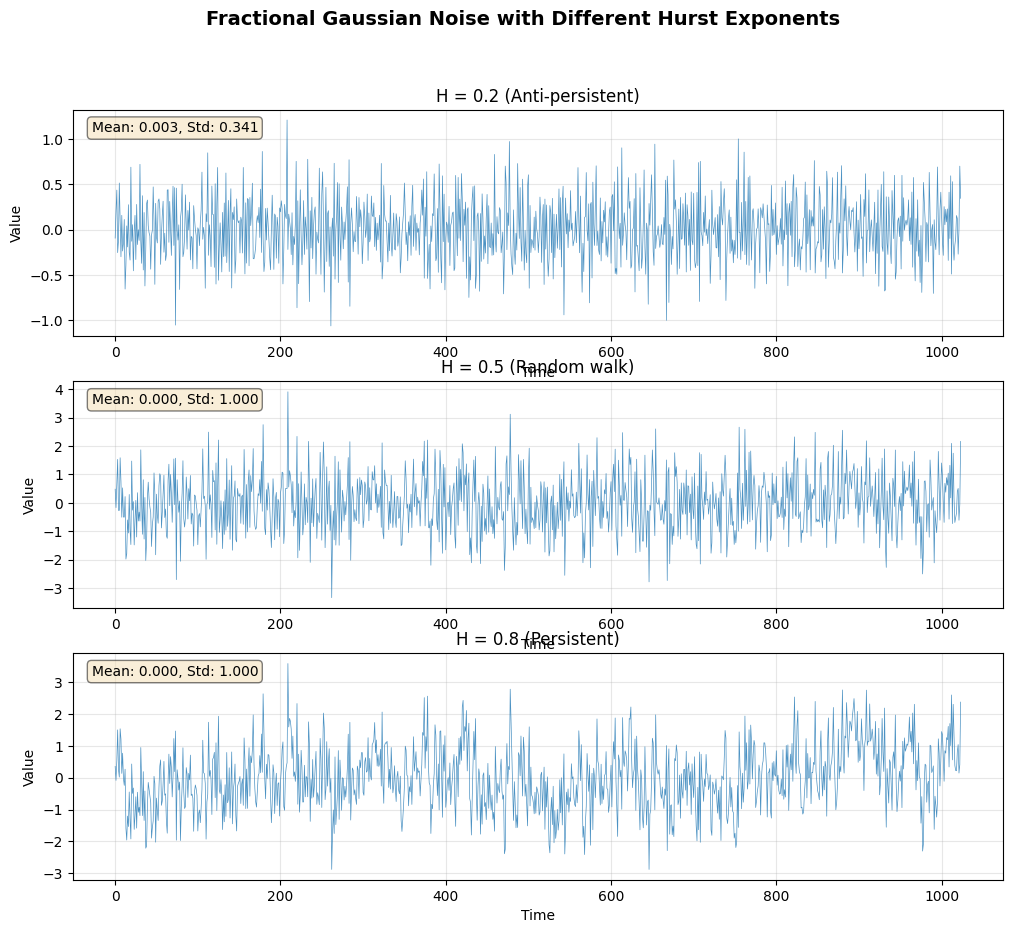

In [2]:
import sys
import warnings
warnings.filterwarnings('ignore')
import time
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')
from tqdm import tqdm

sys.path.insert(0, str(Path().absolute().parent))

from StatTools.analysis.emd_mfdfa import emd_mfdfa, emd_dfa
from StatTools.analysis.dfa import DFA, dfa as dfa_core
from StatTools.generators.kasdin_generator import create_kasdin_generator

"""
Test data generation script for EMD-MFDFA experiments.
This script generates synthetic time series (fractional Gaussian noise)
with known Hurst exponents for validating the EMD-based MFDFA implementation.
"""
def generate_test_dataset(output_dir: str = "test_data"):
    """
    Generate a complete test dataset with various parameters.
    Generates fGn series for:
    - Different Hurst exponents: 0.2, 0.5, 0.8
    Args:
        output_dir: Directory to save generated data
    """
    # Create output directory
    output_path = Path() / output_dir
    output_path.mkdir(exist_ok=True, parents=True)
    # Test parameters
    hurst_values = [0.2, 0.5, 0.8]
    lengths = [2**10, 2**12, 2**14]
    # Generate data for each combination
    for h in hurst_values:
        for length in lengths:
            # Generate signal using Kasdin method
            np.random.seed(42)
            generator = create_kasdin_generator(h=h, length=length, normalize=True)
            signal = generator.get_full_sequence()
            # Save to file
            filename = f"fgn_H{h:.1f}_N{length}.txt"
            filepath = output_path / filename
            np.savetxt(filepath, signal)
    print(f"Dataset generation complete!")
    print(f"Files saved in: {output_path}")
def plot_sample_series(save_dir: str = "figures"):
    """
    Plot sample time series for visual inspection.
    Args:
        save_dir: Directory to save figures
    """
    # Create figures directory
    fig_path = Path() / save_dir
    fig_path.mkdir(exist_ok=True, parents=True)
    # Parameters
    length = 2**10
    hurst_values = [0.2, 0.5, 0.8]
    # Create figure
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    fig.suptitle(
        "Fractional Gaussian Noise with Different Hurst Exponents",
        fontsize=14,
        fontweight="bold",
    )
    for idx, (h, ax) in enumerate(zip(hurst_values, axes)):
        # Generate signal
        np.random.seed(42)
        generator = create_kasdin_generator(h=h, length=length, normalize=True)
        signal = generator.get_full_sequence()
        # Plot
        ax.plot(signal, linewidth=0.5, alpha=0.8)
        ax.set_title(
            f'H = {h:.1f} ({"Anti-persistent" if h < 0.5 else "Random walk" if h == 0.5 else "Persistent"})',
            fontsize=12,
        )
        ax.set_xlabel("Time", fontsize=10)
        ax.set_ylabel("Value", fontsize=10)
        ax.grid(True, alpha=0.3)
        # Add statistics text
        stats_text = f"Mean: {np.mean(signal):.3f}, Std: {np.std(signal):.3f}"
        ax.text(
            0.02,
            0.95,
            stats_text,
            transform=ax.transAxes,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
        )
    plt.show()
def test_generator_basic():
    """
    Basic test to verify generator is working correctly.
    """
    try:
        # Test with H=0.7, short sequence
        np.random.seed(123)
        generator = create_kasdin_generator(h=0.7, length=256, normalize=True)
        signal = generator.get_full_sequence()
        # Test with different H values
        for h in [0.3, 0.5, 0.8]:
            np.random.seed(456)
            generator = create_kasdin_generator(h=h, length=512, normalize=True)
            signal = generator.get_full_sequence()
        return True
    except Exception as e:
        print(f"\nTest failed with error: {e}")
        import traceback
        traceback.print_exc()
        return False
if test_generator_basic():
    plot_sample_series()


## Stage 2: Systematic Experiments


H = 0.2 (антиперс.)
    Средняя оценка H: 0.2376 ± 0.0231
    Истинное H:       0.2000
    MAE:              0.0376 ± 0.0231
    Успешных:         10/10
H = 0.3 (антиперс.)
    Средняя оценка H: 0.3081 ± 0.0257
    Истинное H:       0.3000
    MAE:              0.0210 ± 0.0170
    Успешных:         10/10
H = 0.4 (антиперс.)
    Средняя оценка H: 0.3797 ± 0.0405
    Истинное H:       0.4000
    MAE:              0.0394 ± 0.0224
    Успешных:         10/10
H = 0.5 (случ. блужд.)
    Средняя оценка H: 0.4630 ± 0.0436
    Истинное H:       0.5000
    MAE:              0.0519 ± 0.0240
    Успешных:         10/10
H = 0.6 (персистент.)
    Средняя оценка H: 0.5433 ± 0.0283
    Истинное H:       0.6000
    MAE:              0.0567 ± 0.0283
    Успешных:         10/10
H = 0.7 (персистент.)
    Средняя оценка H: 0.5689 ± 0.0317
    Истинное H:       0.7000
    MAE:              0.1311 ± 0.0317
    Успешных:         10/10
H = 0.8 (персистент.)
    Средняя оценка H: 0.6493 ± 0.0579
    Истинное H:

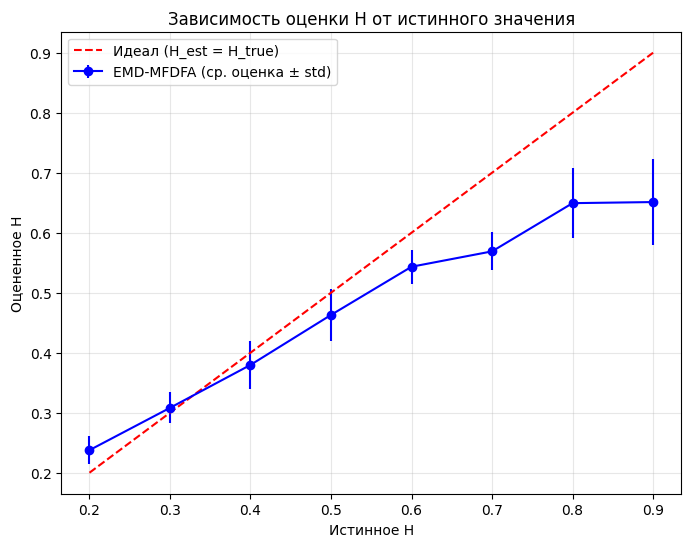


Результаты сохранены:
  JSON: /Users/se7go/IdeaProjects/FluctuationAnalysisTools1/research/results/stage2_systematic_results.json
  TXT:  /Users/se7go/IdeaProjects/FluctuationAnalysisTools1/research/results/stage2_systematic_results.txt


In [2]:
H_VALUES = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
N = 2048
N_REALIZATIONS = 10

results = {
    "parameters": {
        "H_values": H_VALUES,
        "N": N,
        "n_realizations": N_REALIZATIONS,
    },
    "experiments": [],
}

total_experiments = len(H_VALUES) * N_REALIZATIONS
current = 0

for H_true in H_VALUES:
    print(
        f"H = {H_true} ({'антиперс.' if H_true < 0.5 else 'случ. блужд.' if H_true == 0.5 else 'персистент.'})"
    )

    h_estimates = []

    pbar = range(N_REALIZATIONS)

    for i in pbar:
        current += 1

        try:
            seed = 1000 * int(H_true * 10) + i  # Уникальный seed
            generator = create_kasdin_generator(h=H_true, length=N, normalize=True)
            np.random.seed(seed)  # Для воспроизводимости
            signal = generator.get_full_sequence()

            q_vals, h_q, _ = emd_mfdfa(signal)
            H_est = h_q[np.argmin(np.abs(q_vals - 2.0))]
            h_estimates.append(H_est)

            results["experiments"].append({

                    "H_true": H_true,
                    "realization": i,
                    "seed": seed,
                    "H_estimated": float(H_est),
                    "error": float(abs(H_est - H_true)),
                })


        except Exception as e:
            print(f"\n  Ошибка в реализации {i}: {e}")
            h_estimates.append(np.nan)

    h_estimates = np.array(h_estimates)
    valid = ~np.isnan(h_estimates)

    if np.sum(valid) > 0:
        mean_est = np.mean(h_estimates[valid])
        std_est = np.std(h_estimates[valid])
        mean_error = np.mean(np.abs(h_estimates[valid] - H_true))
        std_error = np.std(np.abs(h_estimates[valid] - H_true))

        
        print(f"    Средняя оценка H: {mean_est:.4f} ± {std_est:.4f}")
        print(f"    Истинное H:       {H_true:.4f}")
        print(f"    MAE:              {mean_error:.4f} ± {std_error:.4f}")
        print(f"    Успешных:         {np.sum(valid)}/{N_REALIZATIONS}")

        # Сохранение сводки
        results[f"summary_H_{H_true}"] = {
            "H_true": H_true,
            "mean_estimate": float(mean_est),
            "std_estimate": float(std_est),
            "mean_error": float(mean_error),
            "std_error": float(std_error),
            "n_successful": int(np.sum(valid)),
        }

print(
    f"\n{'H истинное':>12} {'H среднее':>12} {'Станд. откл.':>14} {'MAE':>10} {'σ(MAE)':>10}"
)

all_errors = []
for H_true in H_VALUES:
    key = f"summary_H_{H_true}"
    if key in results:
        s = results[key]
        print(
            f"{s['H_true']:>12.2f} {s['mean_estimate']:>12.4f} "
            f"{s['std_estimate']:>14.4f} {s['mean_error']:>10.4f} "
            f"{s['std_error']:>10.4f}"
        )
        all_errors.append(s["mean_error"])

if all_errors:
    print(f"{'Общая MAE:':>40} {np.mean(all_errors):>10.4f}")
    print(f"{'Макс. MAE:':>40} {np.max(all_errors):>10.4f}")
    print(f"{'Мин. MAE:':>40} {np.min(all_errors):>10.4f}")

    plt.figure(figsize=(8, 6))
    true_vals = [s['H_true'] for s in results.values() if isinstance(s, dict) and 'H_true' in s and 'mean_estimate' in s]
    est_vals = [s['mean_estimate'] for s in results.values() if isinstance(s, dict) and 'H_true' in s and 'mean_estimate' in s]
    err_vals = [s['std_estimate'] for s in results.values() if isinstance(s, dict) and 'H_true' in s and 'std_estimate' in s]
    
    plt.errorbar(true_vals, est_vals, yerr=err_vals, fmt='o-', color='blue', label='EMD-MFDFA (ср. оценка ± std)')
    plt.plot([min(H_VALUES), max(H_VALUES)], [min(H_VALUES), max(H_VALUES)], 'r--', label='Идеал (H_est = H_true)')
    plt.title('Зависимость оценки H от истинного значения')
    plt.xlabel('Истинное H')
    plt.ylabel('Оцененное H')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

output_dir = Path().absolute() / "results"
output_dir.mkdir(exist_ok=True)

json_file = output_dir / "stage2_systematic_results.json"
with open(json_file, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

txt_file = output_dir / "stage2_systematic_results.txt"
with open(txt_file, "w", encoding="utf-8") as f:
    f.write("Этап 2: Систематические эксперименты\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"Параметры:\n")
    f.write(f"  N = {N}\n")
    f.write(f"  Реализаций: {N_REALIZATIONS}\n")
    f.write(f"\n")
    f.write(
        f"{'H_true':>10} {'H_mean':>10} {'H_std':>10} {'MAE':>10} {'MAE_std':>10}\n")
    f.write("-" * 80 + "\n")

    for H_true in H_VALUES:
        key = f"summary_H_{H_true}"
        if key in results:
            s = results[key]
            f.write(
                f"{s['H_true']:>10.2f} {s['mean_estimate']:>10.4f} "
                f"{s['std_estimate']:>10.4f} {s['mean_error']:>10.4f} "
                f"{s['std_error']:>10.4f}\n"
            )

    f.write("\n")
    if all_errors:
        f.write(f"Общая MAE: {np.mean(all_errors):.4f}\n")
        f.write(f"Макс. MAE: {np.max(all_errors):.4f}\n")
        f.write(f"Мин. MAE: {np.min(all_errors):.4f}\n")

print(f"\nРезультаты сохранены:")
print(f"  JSON: {json_file}")
print(f"  TXT:  {txt_file}")


## Stage 3: Limitations


Эксперимент 1: Влияние длины ряда N
    H: 0.5450 ± 0.0774, MAE: 0.1550
    H: 0.4795 ± 0.0319, MAE: 0.2205
    H: 0.5654 ± 0.0449, MAE: 0.1346
    H: 0.5972 ± 0.0380, MAE: 0.1028
    H: 0.6045 ± 0.0299, MAE: 0.0955


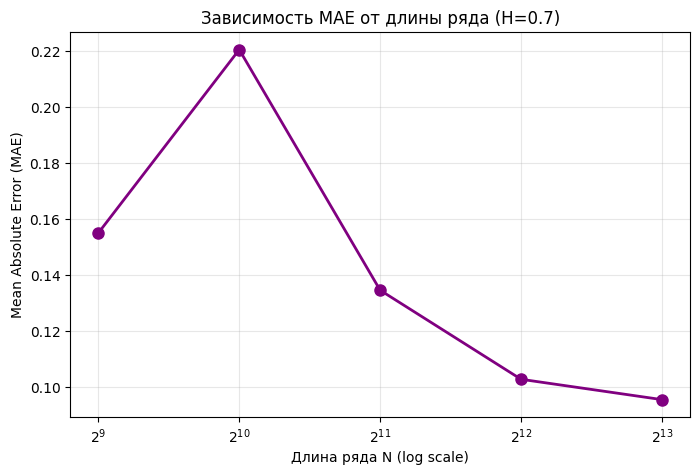

Эксперимент 2: Влияние уровня шума (SNR)
    H: 0.5411 ± 0.0374, MAE: 0.1589
    H: 0.5673 ± 0.0536, MAE: 0.1327
    H: 0.5680 ± 0.0506, MAE: 0.1320
    H: 0.5654 ± 0.0485, MAE: 0.1346
    H: 0.5474 ± 0.0501, MAE: 0.1526


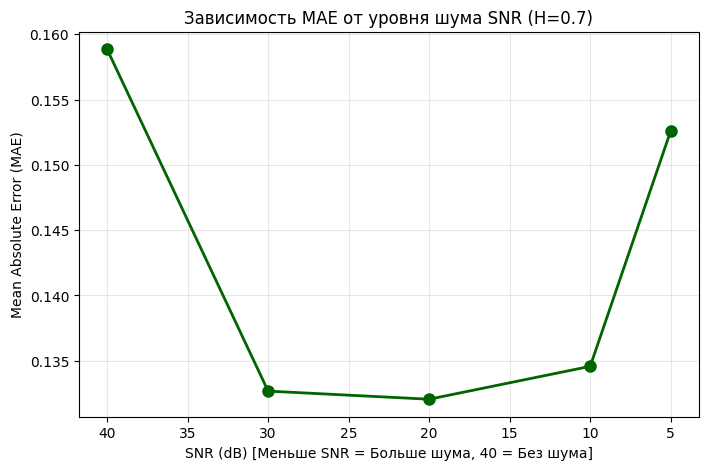


Результаты сохранены:
  Эксп. 1: /Users/se7go/IdeaProjects/FluctuationAnalysisTools1/research/results/stage3_exp1_length_effect.json
  Эксп. 2: /Users/se7go/IdeaProjects/FluctuationAnalysisTools1/research/results/stage3_exp2_noise_effect.json
  Отчёт:   /Users/se7go/IdeaProjects/FluctuationAnalysisTools1/research/results/stage3_limitations_results.txt


In [3]:
# ЭКСПЕРИМЕНТ 1: Влияние длины ряда

print("Эксперимент 1: Влияние длины ряда N")

H_TRUE = 0.7
N_VALUES = [512, 1024, 2048, 4096, 8192]
N_REALIZATIONS = 10

results_exp1 = {
    "parameters": {
        "H_true": H_TRUE,
        "N_values": N_VALUES,
        "n_realizations": N_REALIZATIONS,
    },
    "experiments": [],
}

for N in N_VALUES:

    h_estimates = []

    for i in range(N_REALIZATIONS):
        try:
            seed = 7000 + N + i
            generator = create_kasdin_generator(h=H_TRUE, length=N, normalize=True)
            np.random.seed(seed)
            signal = generator.get_full_sequence()

            q_vals, h_q, _ = emd_mfdfa(signal)
            H_est = h_q[np.argmin(np.abs(q_vals - 2.0))]
            h_estimates.append(H_est)

            results_exp1["experiments"].append({

                    "N": N,
                    "realization": i,
                    "H_estimated": float(H_est),
                    "error": float(abs(H_est - H_TRUE)),
                })

        except Exception as e:
            print(f"    Ошибка: {e}")
            h_estimates.append(np.nan)

    h_estimates = np.array(h_estimates)
    valid = ~np.isnan(h_estimates)

    if np.sum(valid) > 0:
        mean_est = np.mean(h_estimates[valid])
        std_est = np.std(h_estimates[valid])
        mean_error = np.mean(np.abs(h_estimates[valid] - H_TRUE))

        
        print(f"    H: {mean_est:.4f} ± {std_est:.4f}, MAE: {mean_error:.4f}")

        results_exp1[f"summary_N_{N}"] = {
            "N": N,
            "mean_estimate": float(mean_est),
            "std_estimate": float(std_est),
            "mean_error": float(mean_error),
        }

plt.figure(figsize=(8, 5))
n_vals = [s['N'] for s in results_exp1.values() if isinstance(s, dict) and 'N' in s]
mae_vals = [s['mean_error'] for s in results_exp1.values() if isinstance(s, dict) and 'mean_error' in s]
plt.plot(n_vals, mae_vals, 'o-', color='purple', linewidth=2, markersize=8)
plt.xscale('log', base=2)
plt.title('Зависимость MAE от длины ряда (H=0.7)')
plt.xlabel('Длина ряда N (log scale)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.grid(True, alpha=0.3)
plt.show()

# Эксперимент 2: Влияние шума (SNR)

print("Эксперимент 2: Влияние уровня шума (SNR)")

N = 2048
SNR_VALUES = [np.inf, 30, 20, 10, 5]  # dB (inf = без шума)

results_exp2 = {
    "parameters": {
        "H_true": H_TRUE,
        "N": N,
        "SNR_values": SNR_VALUES,
        "n_realizations": N_REALIZATIONS,
    },
    "experiments": [],
}

for SNR in SNR_VALUES:
    snr_label = "∞" if SNR == np.inf else f"{SNR}dB"

    h_estimates = []

    for i in range(N_REALIZATIONS):
        try:
            seed = 8000 + int(SNR if SNR != np.inf else 999) + i
            generator = create_kasdin_generator(h=H_TRUE, length=N, normalize=True)
            np.random.seed(seed)
            signal = generator.get_full_sequence()

            if SNR != np.inf:
                signal_power = np.mean(signal**2)
                noise_power = signal_power / (10 ** (SNR / 10))
                noise = np.random.normal(0, np.sqrt(noise_power), len(signal))
                signal = signal + noise

            q_vals, h_q, _ = emd_mfdfa(signal)
            H_est = h_q[np.argmin(np.abs(q_vals - 2.0))]
            h_estimates.append(H_est)

            results_exp2["experiments"].append({

                    "SNR": float(SNR) if SNR != np.inf else None,
                    "realization": i,
                    "H_estimated": float(H_est),
                    "error": float(abs(H_est - H_TRUE)),
                })

        except Exception as e:
            print(f"    Ошибка: {e}")
            h_estimates.append(np.nan)

    h_estimates = np.array(h_estimates)
    valid = ~np.isnan(h_estimates)

    if np.sum(valid) > 0:
        mean_est = np.mean(h_estimates[valid])
        std_est = np.std(h_estimates[valid])
        mean_error = np.mean(np.abs(h_estimates[valid] - H_TRUE))

        
        print(f"    H: {mean_est:.4f} ± {std_est:.4f}, MAE: {mean_error:.4f}")

        snr_key = "inf" if SNR == np.inf else str(int(SNR))
        results_exp2[f"summary_SNR_{snr_key}"] = {
            "SNR": float(SNR) if SNR != np.inf else None,
            "mean_estimate": float(mean_est),
            "std_estimate": float(std_est),
            "mean_error": float(mean_error),
        }

plt.figure(figsize=(8, 5))
snr_vals = []
mae_vals = []
for s in results_exp2.values():
    if isinstance(s, dict) and 'SNR' in s and 'mean_error' in s:
        # Для inf (без шума) используем условное значение (например 40)
        snr_vals.append(40 if s['SNR'] is None else s['SNR'])
        mae_vals.append(s['mean_error'])
        
plt.plot(snr_vals, mae_vals, 'o-', color='darkgreen', linewidth=2, markersize=8)
plt.gca().invert_xaxis()  # Инвертируем ось X, чтобы шум рос слева направо
plt.title('Зависимость MAE от уровня шума SNR (H=0.7)')
plt.xlabel('SNR (dB) [Меньше SNR = Больше шума, 40 = Без шума]')
plt.ylabel('Mean Absolute Error (MAE)')
plt.grid(True, alpha=0.3)
plt.show()

output_dir = Path().absolute() / "results"
output_dir.mkdir(exist_ok=True)

# Эксперимент 1
json_file1 = output_dir / "stage3_exp1_length_effect.json"
with open(json_file1, "w", encoding="utf-8") as f:
    json.dump(results_exp1, f, indent=2, ensure_ascii=False)

# Эксперимент 2
json_file2 = output_dir / "stage3_exp2_noise_effect.json"
with open(json_file2, "w", encoding="utf-8") as f:
    json.dump(results_exp2, f, indent=2, ensure_ascii=False)

txt_file = output_dir / "stage3_limitations_results.txt"
with open(txt_file, "w", encoding="utf-8") as f:
    f.write("Этап 3: Исследование ограничений\n")
    f.write("=" * 80 + "\n\n")

    f.write("Эксперимент 1: Влияние длины ряда\n")
    f.write("-" * 80 + "\n")
    f.write(f"{'N':>10} {'H_mean':>10} {'H_std':>10} {'MAE':>10}\n")
    f.write("-" * 80 + "\n")

    for N in N_VALUES:
        key = f"summary_N_{N}"
        if key in results_exp1:
            s = results_exp1[key]
            f.write(
                f"{s['N']:>10} {s['mean_estimate']:>10.4f} "
                f"{s['std_estimate']:>10.4f} {s['mean_error']:>10.4f}\n"
            )

    f.write("\n\nЭксперимент 2: Влияние уровня шума\n")
    f.write("-" * 80 + "\n")
    f.write(f"{'SNR (dB)':>10} {'H_mean':>10} {'H_std':>10} {'MAE':>10}\n")
    f.write("-" * 80 + "\n")

    for SNR in SNR_VALUES:
        snr_key = "inf" if SNR == np.inf else str(int(SNR))
        key = f"summary_SNR_{snr_key}"
        if key in results_exp2:
            s = results_exp2[key]
            snr_label = "∞" if s["SNR"] is None else f"{int(s['SNR'])}"
            f.write(
                f"{snr_label:>10} {s['mean_estimate']:>10.4f} "
                f"{s['std_estimate']:>10.4f} {s['mean_error']:>10.4f}\n"
            )

print(f"\nРезультаты сохранены:")
print(f"  Эксп. 1: {json_file1}")
print(f"  Эксп. 2: {json_file2}")
print(f"  Отчёт:   {txt_file}")


## Stage 4: Comparison with other methods


    EMD-MFDFA: H = 0.2207 ± 0.0073, MAE = 0.0207, время = 13.13с
    DFA:       H = 0.2522 ± 0.0049, MAE = 0.0522, время = 0.80с
    Лучший метод: EMD-MFDFA (улучшение на 60.4%)
    EMD-MFDFA: H = 0.3026 ± 0.0125, MAE = 0.0087, время = 12.99с
    DFA:       H = 0.3316 ± 0.0066, MAE = 0.0316, время = 0.80с
    Лучший метод: EMD-MFDFA (улучшение на 72.5%)
    EMD-MFDFA: H = 0.3885 ± 0.0142, MAE = 0.0168, время = 12.77с
    DFA:       H = 0.4175 ± 0.0069, MAE = 0.0175, время = 0.81с
    Лучший метод: EMD-MFDFA (улучшение на 4.2%)
    EMD-MFDFA: H = 0.4773 ± 0.0131, MAE = 0.0227, время = 12.72с
    DFA:       H = 0.5069 ± 0.0080, MAE = 0.0086, время = 0.79с
    Лучший метод: DFA (улучшение на 62.0%)
    EMD-MFDFA: H = 0.5667 ± 0.0236, MAE = 0.0372, время = 12.49с
    DFA:       H = 0.6003 ± 0.0086, MAE = 0.0059, время = 0.80с
    Лучший метод: DFA (улучшение на 84.1%)
    EMD-MFDFA: H = 0.6364 ± 0.0217, MAE = 0.0636, время = 12.14с
    DFA:       H = 0.6923 ± 0.0105, MAE = 0.0109, время = 

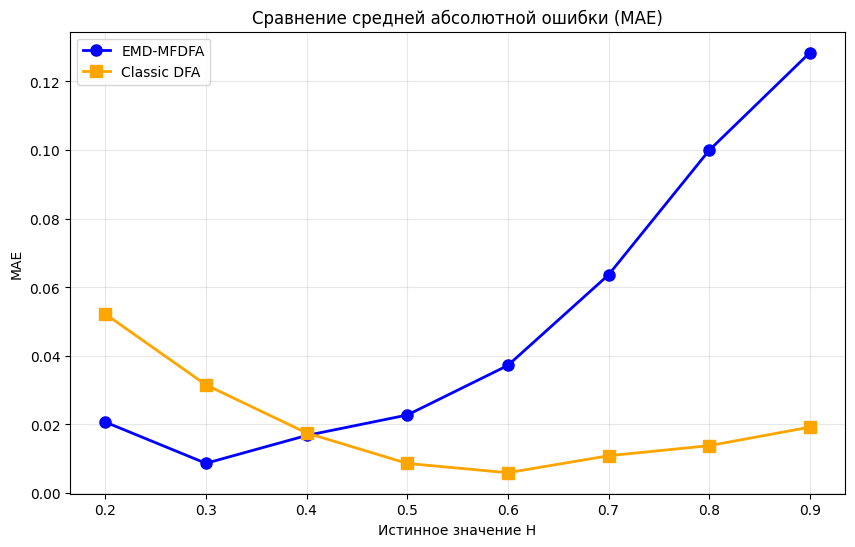


               Итог: DFA лучше на 59.9%

Результаты сохранены:
  JSON: /Users/se7go/IdeaProjects/FluctuationAnalysisTools1/research/results/stage4_comparison_results.json
  TXT:  /Users/se7go/IdeaProjects/FluctuationAnalysisTools1/research/results/stage4_comparison_results.txt


In [ ]:
H_VALUES = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
N = 2**16  # 65536 — as in Qian et al. (2011), Section 3.1
N_REALIZATIONS = 10

results = {
    "parameters": {
        "H_values": H_VALUES,
        "N": N,
        "n_realizations": N_REALIZATIONS,
    },
    "experiments": [],
}

for H_true in H_VALUES:

    emd_estimates = []
    dfa_estimates = []
    emd_times = []
    dfa_times = []

    pbar = range(N_REALIZATIONS)

    for i in pbar:
        try:
            seed = 9000 + int(H_true * 10) + i
            generator = create_kasdin_generator(h=H_true, length=N, normalize=True)
            np.random.seed(seed)
            signal = generator.get_full_sequence()

            start_time = time.time()
            q_vals, h_q, _ = emd_mfdfa(signal)
            H_emd = h_q[np.argmin(np.abs(q_vals - 2.0))]
            emd_time = time.time() - start_time
            emd_estimates.append(H_emd)
            emd_times.append(emd_time)

            start_time = time.time()
            dfa = DFA(signal, degree=2, root=False)
            H_dfa = dfa.find_h()
            dfa_time = time.time() - start_time
            dfa_estimates.append(H_dfa)
            dfa_times.append(dfa_time)

            results["experiments"].append({
                    "H_true": H_true,
                    "realization": i,
                    "seed": seed,
                    "emd_estimate": float(H_emd),
                    "emd_error": float(abs(H_emd - H_true)),
                    "emd_time": float(emd_time),
                    "dfa_estimate": float(H_dfa),
                    "dfa_error": float(abs(H_dfa - H_true)),
                    "dfa_time": float(dfa_time),
                })


        except Exception as e:
            print(f"\n  Ошибка в реализации {i}: {e}")
            emd_estimates.append(np.nan)
            dfa_estimates.append(np.nan)

    emd_estimates = np.array(emd_estimates)
    dfa_estimates = np.array(dfa_estimates)
    emd_times = np.array(emd_times)
    dfa_times = np.array(dfa_times)

    emd_valid = ~np.isnan(emd_estimates)
    dfa_valid = ~np.isnan(dfa_estimates)

    if np.sum(emd_valid) > 0 and np.sum(dfa_valid) > 0:
        # EMD-MFDFA статистика
        emd_mean = np.mean(emd_estimates[emd_valid])
        emd_std = np.std(emd_estimates[emd_valid])
        emd_mae = np.mean(np.abs(emd_estimates[emd_valid] - H_true))
        emd_time_mean = np.mean(emd_times[emd_valid])

        # DFA статистика
        dfa_mean = np.mean(dfa_estimates[dfa_valid])
        dfa_std = np.std(dfa_estimates[dfa_valid])
        dfa_mae = np.mean(np.abs(dfa_estimates[dfa_valid] - H_true))
        dfa_time_mean = np.mean(dfa_times[dfa_valid])


        print(
            f"    EMD-MFDFA: H = {emd_mean:.4f} ± {emd_std:.4f}, MAE = {emd_mae:.4f}, время = {emd_time_mean:.2f}с"
        )
        print(
            f"    DFA:       H = {dfa_mean:.4f} ± {dfa_std:.4f}, MAE = {dfa_mae:.4f}, время = {dfa_time_mean:.2f}с"
        )

        if emd_mae < dfa_mae:
            winner = "EMD-MFDFA"
            improvement = ((dfa_mae - emd_mae) / dfa_mae) * 100
        else:
            winner = "DFA"
            improvement = ((emd_mae - dfa_mae) / emd_mae) * 100

        print(f"    Лучший метод: {winner} (улучшение на {improvement:.1f}%)")

        results[f"summary_H_{H_true}"] = {
            "H_true": H_true,
            "emd": {
                "mean": float(emd_mean),
                "std": float(emd_std),
                "mae": float(emd_mae),
                "time_mean": float(emd_time_mean),
            },
            "dfa": {
                "mean": float(dfa_mean),
                "std": float(dfa_std),
                "mae": float(dfa_mae),
                "time_mean": float(dfa_time_mean),
            },
            "winner": winner,
            "improvement_percent": float(improvement),
        }

print(
    f"\n{'H':>6} {'EMD MAE':>10} {'DFA MAE':>10} {'EMD время':>12} {'DFA время':>12} {'Лучший':>12}"
)

emd_total_mae = []
dfa_total_mae = []
emd_wins = 0
dfa_wins = 0

for H_true in H_VALUES:
    key = f"summary_H_{H_true}"
    if key in results:
        s = results[key]
        print(
            f"{s['H_true']:>6.2f} {s['emd']['mae']:>10.4f} {s['dfa']['mae']:>10.4f} "
            f"{s['emd']['time_mean']:>11.2f}s {s['dfa']['time_mean']:>11.2f}s "
            f"{s['winner']:>12}"
        )

        emd_total_mae.append(s["emd"]["mae"])
        dfa_total_mae.append(s["dfa"]["mae"])

        if s["winner"] == "EMD-MFDFA":
            emd_wins += 1
        else:
            dfa_wins += 1

if emd_total_mae and dfa_total_mae:
    emd_avg = np.mean(emd_total_mae)
    dfa_avg = np.mean(dfa_total_mae)

    plt.figure(figsize=(10, 6))
    true_vals = [s['H_true'] for s in results.values() if isinstance(s, dict) and 'H_true' in s]
    emd_errs = [s['emd']['mae'] for s in results.values() if isinstance(s, dict) and 'emd' in s]
    dfa_errs = [s['dfa']['mae'] for s in results.values() if isinstance(s, dict) and 'dfa' in s]
    
    plt.plot(true_vals, emd_errs, 'o-', color='blue', linewidth=2, markersize=8, label='EMD-MFDFA')
    plt.plot(true_vals, dfa_errs, 's-', color='orange', linewidth=2, markersize=8, label='Classic DFA')
    plt.title('Сравнение средней абсолютной ошибки (MAE)')
    plt.xlabel('Истинное значение H')
    plt.ylabel('MAE')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    if emd_avg < dfa_avg:
        overall_improvement = ((dfa_avg - emd_avg) / dfa_avg) * 100
        print(f"\n{'Итог:':>20} EMD-MFDFA лучше на {overall_improvement:.1f}%")
    else:
        overall_improvement = ((emd_avg - dfa_avg) / emd_avg) * 100
        print(f"\n{'Итог:':>20} DFA лучше на {overall_improvement:.1f}%")

output_dir = Path().absolute() / "results"
output_dir.mkdir(exist_ok=True)

json_file = output_dir / "stage4_comparison_results.json"
with open(json_file, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

txt_file = output_dir / "stage4_comparison_results.txt"
with open(txt_file, "w", encoding="utf-8") as f:
    f.write("Этап 4: Сравнительный анализ (EMD-MFDFA vs DFA)\n")
    f.write("=" * 80 + "\n\n")
    f.write(
        f"{'H_true':>8} {'EMD_MAE':>10} {'DFA_MAE':>10} {'EMD_time':>10} {'DFA_time':>10} {'Winner':>12}\n")
    f.write("-" * 80 + "\n")

    for H_true in H_VALUES:
        key = f"summary_H_{H_true}"
        if key in results:
            s = results[key]
            f.write(
                f"{s['H_true']:>8.2f} {s['emd']['mae']:>10.4f} {s['dfa']['mae']:>10.4f} "
                f"{s['emd']['time_mean']:>10.2f} {s['dfa']['time_mean']:>10.2f} "
                f"{s['winner']:>12}\n"
            )

    f.write("\n")
    if emd_total_mae and dfa_total_mae:
        f.write(f"Средняя MAE:\n")
        f.write(f"  EMD-MFDFA: {np.mean(emd_total_mae):.4f}\n")
        f.write(f"  DFA:       {np.mean(dfa_total_mae):.4f}\n\n")
        f.write(f"Побед:\n")
        f.write(f"  EMD-MFDFA: {emd_wins}\n")
        f.write(f"  DFA:       {dfa_wins}\n")

print(f"\nРезультаты сохранены:")
print(f"  JSON: {json_file}")
print(f"  TXT:  {txt_file}")


## Stage 5: Эксперименты по мотивам статьи

Воспроизведение ключевых результатов:
1. **Эксп. 5.1** — MSE(H) vs длина сигнала N (EMD-DFA, нескольких H, больше реализаций) → определяю оптимальную N
2. **Эксп. 5.2** — EMD-DFA: H_est vs H_true, H₀ ∈ [0.05, 0.95], N = 2^16, 100 реализаций (Fig 1b статьи)
3. **Эксп. 5.3** — Сравнение EMD-DFA vs DFA-1/2/3: отношение H/H₀ (Fig 2 статьи)
4. **Эксп. 5.4** — Обновлённый H_est vs H_true для EMD-MFDFA с оптимальной N

Эксп. 5.1: MSE vs длина сигнала (EMD-DFA)
  H₀=0.3, N=   512: H_est=0.3071 ± 0.0418, MSE=0.001798
  H₀=0.3, N=  1024: H_est=0.3089 ± 0.0326, MSE=0.001143
  H₀=0.3, N=  2048: H_est=0.3088 ± 0.0346, MSE=0.001272
  H₀=0.3, N=  4096: H_est=0.3046 ± 0.0211, MSE=0.000466
  H₀=0.3, N=  8192: H_est=0.3043 ± 0.0173, MSE=0.000318
  H₀=0.3, N= 16384: H_est=0.3054 ± 0.0165, MSE=0.000301
  H₀=0.3, N= 32768: H_est=0.3055 ± 0.0128, MSE=0.000194
  H₀=0.3, N= 65536: H_est=0.3027 ± 0.0081, MSE=0.000072
  H₀=0.3, N=131072: H_est=0.3074 ± 0.0092, MSE=0.000139
  H₀=0.5, N=   512: H_est=0.4561 ± 0.0650, MSE=0.006153
  H₀=0.5, N=  1024: H_est=0.4407 ± 0.0496, MSE=0.005983
  H₀=0.5, N=  2048: H_est=0.4488 ± 0.0495, MSE=0.005068
  H₀=0.5, N=  4096: H_est=0.4672 ± 0.0359, MSE=0.002367
  H₀=0.5, N=  8192: H_est=0.4697 ± 0.0248, MSE=0.001532
  H₀=0.5, N= 16384: H_est=0.4741 ± 0.0175, MSE=0.000976
  H₀=0.5, N= 32768: H_est=0.4760 ± 0.0128, MSE=0.000740
  H₀=0.5, N= 65536: H_est=0.4828 ± 0.0152, MSE=0.000524
  H₀=0

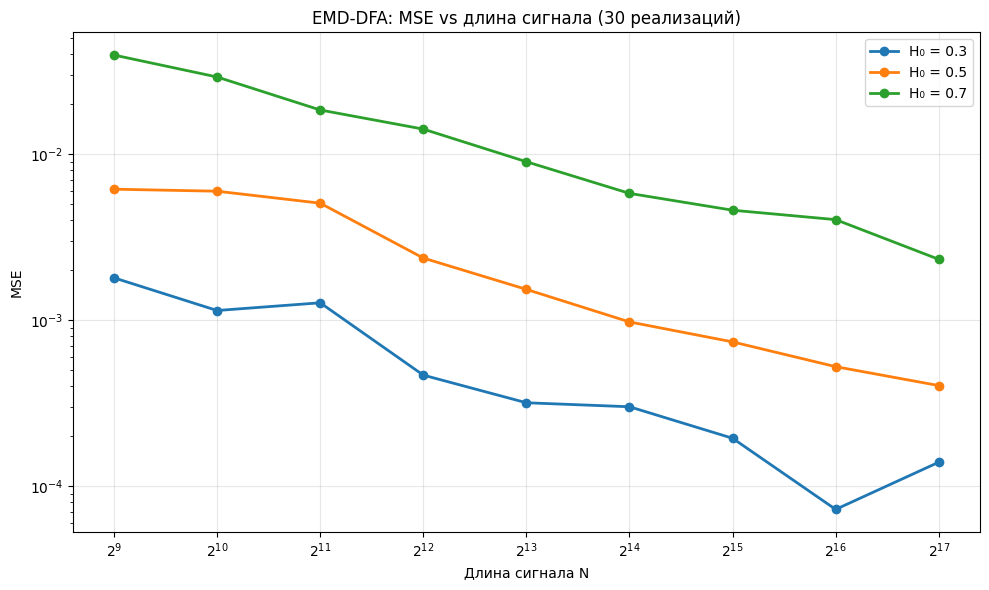

In [4]:
# Эксп. 5.1: MSE vs длина сигнала N (EMD-DFA)
# Цель: определить оптимальную N для устойчивой оценки H

H_VALUES_MSE = [0.3, 0.5, 0.7]
N_VALUES_MSE = [2**k for k in range(9, 18)]  # 512 .. 131072
N_REALIZATIONS_MSE = 30

print("=" * 70)
print("Эксп. 5.1: MSE vs длина сигнала (EMD-DFA)")
print("=" * 70)

mse_results = {}  # {H: {N: [h_estimates]}}

for H_true in H_VALUES_MSE:
    mse_results[H_true] = {}
    for N in N_VALUES_MSE:
        estimates = []
        for i in range(N_REALIZATIONS_MSE):
            np.random.seed(10000 + int(H_true * 100) + N + i)
            gen = create_kasdin_generator(h=H_true, length=N, normalize=True)
            signal = gen.get_full_sequence()

            scales, F2_s = emd_dfa(signal)
            if len(scales) < 4:
                estimates.append(np.nan)
                continue
            h_est = np.polyfit(np.log(scales), np.log(np.sqrt(F2_s)), 1)[0]
            estimates.append(h_est)

        arr = np.array(estimates)
        valid = arr[~np.isnan(arr)]
        mse = np.mean((valid - H_true) ** 2) if len(valid) > 0 else np.nan
        mse_results[H_true][N] = {
            "estimates": valid.tolist(),
            "mse": float(mse),
            "mean": float(np.mean(valid)) if len(valid) > 0 else np.nan,
            "std": float(np.std(valid)) if len(valid) > 0 else np.nan,
        }
        print(f"  H₀={H_true:.1f}, N={N:>6d}: "
              f"H_est={np.mean(valid):.4f} ± {np.std(valid):.4f}, "
              f"MSE={mse:.6f}")

plt.figure(figsize=(10, 6))
for H_true in H_VALUES_MSE:
    ns = sorted(mse_results[H_true].keys())
    mses = [mse_results[H_true][n]["mse"] for n in ns]
    plt.plot(ns, mses, "o-", label=f"H₀ = {H_true:.1f}", linewidth=2)

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Длина сигнала N")
plt.ylabel("MSE")
plt.title(f"EMD-DFA: MSE vs длина сигнала ({N_REALIZATIONS_MSE} реализаций)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Эксп. 5.2: EMD-DFA H_est vs H_true (N=8192, 50 реализаций)
  H₀=0.10: H_est=0.1618 ± 0.0102, MAE=0.0618  [110.9с]
  H₀=0.20: H_est=0.2308 ± 0.0139, MAE=0.0308  [110.5с]
  H₀=0.30: H_est=0.3025 ± 0.0201, MAE=0.0147  [112.6с]
  H₀=0.40: H_est=0.3865 ± 0.0163, MAE=0.0170  [110.4с]
  H₀=0.50: H_est=0.4686 ± 0.0261, MAE=0.0353  [111.6с]
  H₀=0.60: H_est=0.5452 ± 0.0275, MAE=0.0552  [107.7с]
  H₀=0.70: H_est=0.6100 ± 0.0377, MAE=0.0900  [102.7с]
  H₀=0.80: H_est=0.6684 ± 0.0412, MAE=0.1316  [97.0с]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


  H₀=0.90: H_est=0.7264 ± 0.0492, MAE=0.1736  [87.3с]

Общее время: 951с


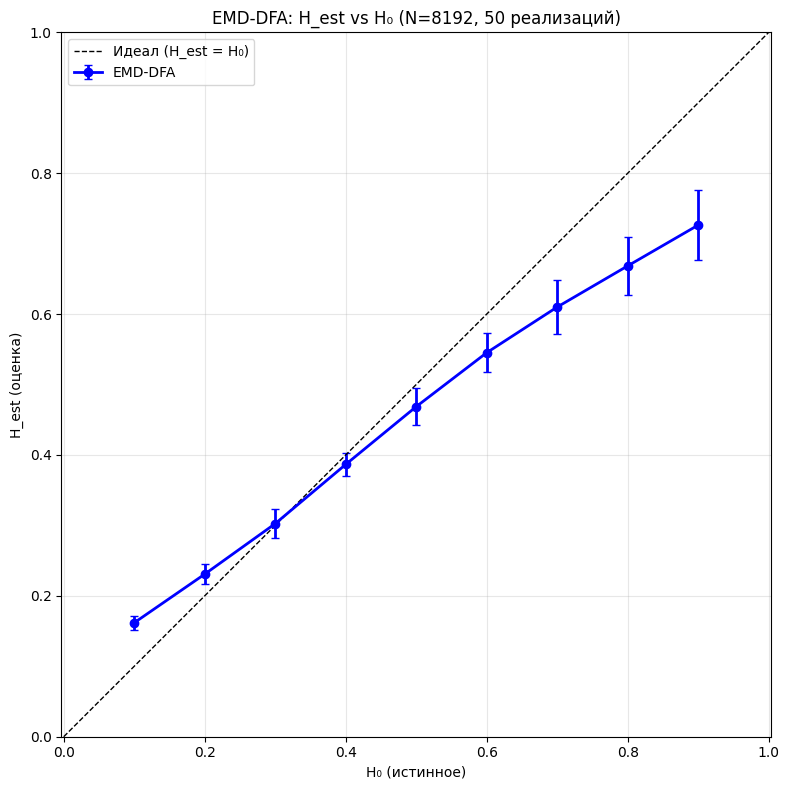

In [4]:
# Эксп. 5.2: EMD-DFA — H_est vs H_true (Fig 1b статьи)

N_FIG1 = 2**13              
H_RANGE_FIG1 = np.arange(0.1, 1.0, 0.1)
N_REALIZATIONS_FIG1 = 50

print("=" * 70)
print(f"Эксп. 5.2: EMD-DFA H_est vs H_true (N={N_FIG1}, {N_REALIZATIONS_FIG1} реализаций)")
print("=" * 70)

fig1_results = {}
t_total = time.time()

for H_true in H_RANGE_FIG1:
    t0 = time.time()
    estimates = []
    for i in range(N_REALIZATIONS_FIG1):
        np.random.seed(20000 + int(H_true * 1000) + i)
        gen = create_kasdin_generator(h=H_true, length=N_FIG1, normalize=True)
        signal = gen.get_full_sequence()

        scales, F2_s = emd_dfa(signal)
        if len(scales) < 4:
            estimates.append(np.nan)
            continue
        h_est = np.polyfit(np.log(scales), np.log(np.sqrt(F2_s)), 1)[0]
        estimates.append(h_est)

    arr = np.array(estimates)
    valid = arr[~np.isnan(arr)]
    elapsed = time.time() - t0
    fig1_results[H_true] = {
        "mean": float(np.mean(valid)),
        "std": float(np.std(valid)),
        "mae": float(np.mean(np.abs(valid - H_true))),
    }
    print(f"  H₀={H_true:.2f}: H_est={np.mean(valid):.4f} ± {np.std(valid):.4f}, "
          f"MAE={np.mean(np.abs(valid - H_true)):.4f}  [{elapsed:.1f}с]")

print(f"\nОбщее время: {time.time() - t_total:.0f}с")

plt.figure(figsize=(8, 8))
h_true_vals = sorted(fig1_results.keys())
h_est_means = [fig1_results[h]["mean"] for h in h_true_vals]
h_est_stds = [fig1_results[h]["std"] for h in h_true_vals]

plt.errorbar(h_true_vals, h_est_means, yerr=h_est_stds,
             fmt="o-", color="blue", capsize=3, label="EMD-DFA", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Идеал (H_est = H₀)", linewidth=1)

plt.xlabel("H₀ (истинное)")
plt.ylabel("H_est (оценка)")
plt.title(f"EMD-DFA: H_est vs H₀ (N={N_FIG1}, {N_REALIZATIONS_FIG1} реализаций)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Эксп. 5.3: H/H₀ — EMD-DFA vs DFA-1/2/3 (N=8192, 50 реал.)
  H₀=0.10: EMD-DFA=0.1609, DFA-1=0.1775  [123.6с]
  H₀=0.20: EMD-DFA=0.2275, DFA-1=0.2421  [122.9с]
  H₀=0.30: EMD-DFA=0.3048, DFA-1=0.3217  [121.3с]
  H₀=0.40: EMD-DFA=0.3877, DFA-1=0.4067  [122.9с]
  H₀=0.50: EMD-DFA=0.4628, DFA-1=0.4872  [121.2с]
  H₀=0.60: EMD-DFA=0.5398, DFA-1=0.5842  [120.1с]
  H₀=0.70: EMD-DFA=0.6114, DFA-1=0.6774  [117.5с]
  H₀=0.80: EMD-DFA=0.6690, DFA-1=0.7748  [110.9с]
  H₀=0.90: EMD-DFA=0.7120, DFA-1=0.8696  [101.2с]

Общее время: 1062с


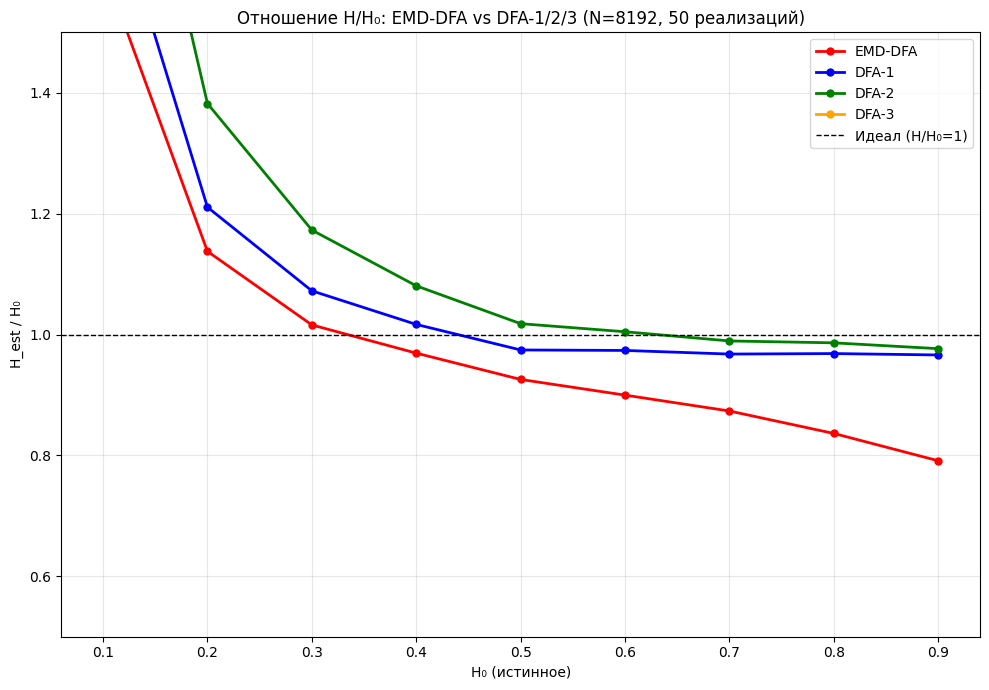

In [5]:
# Эксп. 5.3: Сравнение EMD-DFA vs DFA-1/2/3 — H/H₀ ratio

N_FIG2 = 2**13
H_RANGE_FIG2 = np.arange(0.1, 1.0, 0.1)
N_REALIZATIONS_FIG2 = 50
DFA_DEGREES = [1, 2, 3]

print("=" * 70)
print(f"Эксп. 5.3: H/H₀ — EMD-DFA vs DFA-1/2/3 (N={N_FIG2}, {N_REALIZATIONS_FIG2} реал.)")
print("=" * 70)

fig2_results = {"emd_dfa": {}}
for deg in DFA_DEGREES:
    fig2_results[f"dfa_{deg}"] = {}

t_total = time.time()

for H_true in H_RANGE_FIG2:
    t0 = time.time()
    emd_estimates = []
    dfa_estimates = {deg: [] for deg in DFA_DEGREES}

    for i in range(N_REALIZATIONS_FIG2):
        np.random.seed(30000 + int(H_true * 1000) + i)
        gen = create_kasdin_generator(h=H_true, length=N_FIG2, normalize=True)
        signal = gen.get_full_sequence()

        scales, F2_s = emd_dfa(signal)
        if len(scales) >= 4:
            h_est = np.polyfit(np.log(scales), np.log(np.sqrt(F2_s)), 1)[0]
            emd_estimates.append(h_est)
        else:
            emd_estimates.append(np.nan)

        for deg in DFA_DEGREES:
            dfa_obj = DFA(signal, degree=deg)
            h_dfa = dfa_obj.find_h()
            dfa_estimates[deg].append(h_dfa)

    arr = np.array(emd_estimates)
    valid = arr[~np.isnan(arr)]
    if len(valid) > 0:
        fig2_results["emd_dfa"][H_true] = float(np.mean(valid))

    for deg in DFA_DEGREES:
        arr = np.array(dfa_estimates[deg])
        valid = arr[~np.isnan(arr)]
        if len(valid) > 0:
            fig2_results[f"dfa_{deg}"][H_true] = float(np.mean(valid))

    elapsed = time.time() - t0
    emd_mean = fig2_results["emd_dfa"].get(H_true, float("nan"))
    print(f"  H₀={H_true:.2f}: EMD-DFA={emd_mean:.4f}, "
          f"DFA-1={fig2_results['dfa_1'].get(H_true, float('nan')):.4f}  [{elapsed:.1f}с]")

print(f"\nОбщее время: {time.time() - t_total:.0f}с")

# --- График H/H₀ (Fig 2) ---
plt.figure(figsize=(10, 7))

colors = {"emd_dfa": "red", "dfa_1": "blue", "dfa_2": "green", "dfa_3": "orange"}
labels = {"emd_dfa": "EMD-DFA", "dfa_1": "DFA-1", "dfa_2": "DFA-2", "dfa_3": "DFA-3"}

for method_key in ["emd_dfa"] + [f"dfa_{d}" for d in DFA_DEGREES]:
    data = fig2_results[method_key]
    h0_vals = sorted(data.keys())
    ratios = [data[h0] / h0 for h0 in h0_vals]
    plt.plot(h0_vals, ratios, "o-",
             color=colors[method_key], label=labels[method_key],
             linewidth=2, markersize=5)

plt.axhline(y=1.0, color="black", linestyle="--", linewidth=1, label="Идеал (H/H₀=1)")
plt.xlabel("H₀ (истинное)")
plt.ylabel("H_est / H₀")
plt.title(f"Отношение H/H₀: EMD-DFA vs DFA-1/2/3 (N={N_FIG2}, {N_REALIZATIONS_FIG2} реализаций)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 1.5)
plt.tight_layout()
plt.show()

Эксп. 5.4: EMD-MFDFA H_est vs H_true (N=16384, 100 реализаций)
  H₀=0.10: H_est=0.1570 ± 0.0079, MAE=0.0570  [406.3с]
  H₀=0.20: H_est=0.2251 ± 0.0113, MAE=0.0251  [402.6с]
  H₀=0.30: H_est=0.3034 ± 0.0142, MAE=0.0112  [398.6с]
  H₀=0.40: H_est=0.3892 ± 0.0173, MAE=0.0163  [395.1с]
  H₀=0.50: H_est=0.4745 ± 0.0244, MAE=0.0297  [395.6с]
  H₀=0.60: H_est=0.5546 ± 0.0227, MAE=0.0456  [390.0с]
  H₀=0.70: H_est=0.6263 ± 0.0290, MAE=0.0737  [379.6с]
  H₀=0.80: H_est=0.6885 ± 0.0293, MAE=0.1115  [360.4с]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


  H₀=0.90: H_est=0.7499 ± 0.0349, MAE=0.1501  [321.4с]

Общее время: 3450с


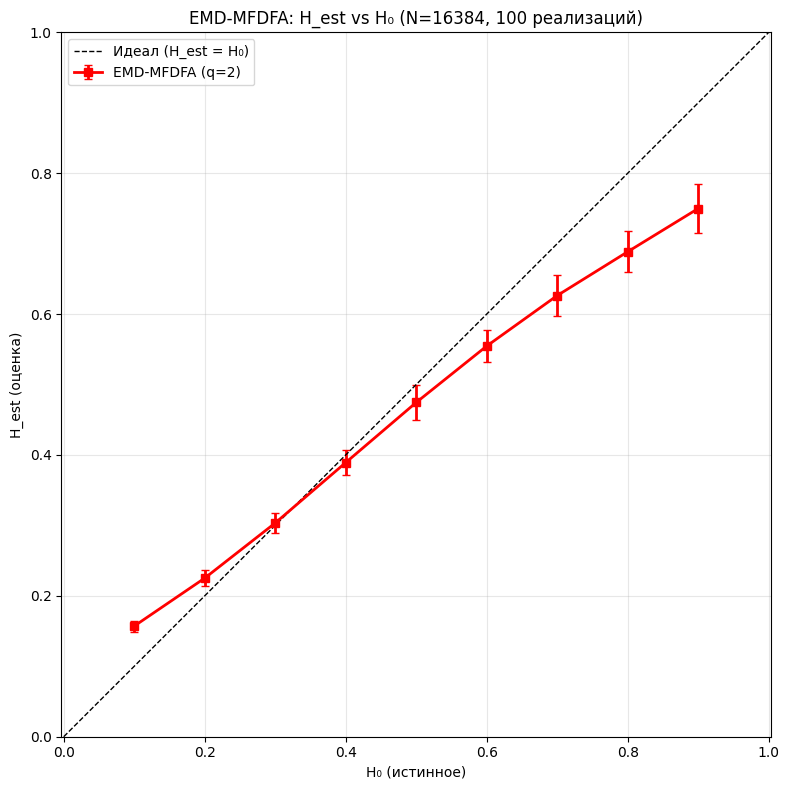


    H₀     H_est        ±σ       MAE
--------------------------------------------------
  0.10    0.1570    0.0079    0.0570
  0.20    0.2251    0.0113    0.0251
  0.30    0.3034    0.0142    0.0112
  0.40    0.3892    0.0173    0.0163
  0.50    0.4745    0.0244    0.0297
  0.60    0.5546    0.0227    0.0456
  0.70    0.6263    0.0290    0.0737
  0.80    0.6885    0.0293    0.1115
  0.90    0.7499    0.0349    0.1501


In [7]:
# Эксп. 5.4: EMD-MFDFA — H_est vs H_true

N_OPT = 2**14

H_RANGE_MFDFA = np.arange(0.1, 1.0, 0.1)
N_REALIZATIONS_MFDFA = 100

print("=" * 70)
print(f"Эксп. 5.4: EMD-MFDFA H_est vs H_true (N={N_OPT}, {N_REALIZATIONS_MFDFA} реализаций)")
print("=" * 70)

mfdfa_results = {}
t_total = time.time()

for H_true in H_RANGE_MFDFA:
    t0 = time.time()
    estimates = []
    for i in range(N_REALIZATIONS_MFDFA):
        np.random.seed(40000 + int(H_true * 1000) + i)
        gen = create_kasdin_generator(h=H_true, length=N_OPT, normalize=True)
        signal = gen.get_full_sequence()

        q_vals, h_q, _ = emd_mfdfa(signal)
        H_est = h_q[np.argmin(np.abs(q_vals - 2.0))]
        estimates.append(H_est)

    arr = np.array(estimates)
    valid = arr[~np.isnan(arr)]
    elapsed = time.time() - t0
    mfdfa_results[H_true] = {
        "mean": float(np.mean(valid)),
        "std": float(np.std(valid)),
        "mae": float(np.mean(np.abs(valid - H_true))),
    }
    print(f"  H₀={H_true:.2f}: H_est={np.mean(valid):.4f} ± {np.std(valid):.4f}, "
          f"MAE={np.mean(np.abs(valid - H_true)):.4f}  [{elapsed:.1f}с]")

print(f"\nОбщее время: {time.time() - t_total:.0f}с")

# --- График H_est vs H_true (EMD-MFDFA) ---
plt.figure(figsize=(8, 8))
h_true_vals = sorted(mfdfa_results.keys())
h_est_means = [mfdfa_results[h]["mean"] for h in h_true_vals]
h_est_stds = [mfdfa_results[h]["std"] for h in h_true_vals]

plt.errorbar(h_true_vals, h_est_means, yerr=h_est_stds,
             fmt="s-", color="red", capsize=3, label="EMD-MFDFA (q=2)", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Идеал (H_est = H₀)", linewidth=1)

plt.xlabel("H₀ (истинное)")
plt.ylabel("H_est (оценка)")
plt.title(f"EMD-MFDFA: H_est vs H₀ (N={N_OPT}, {N_REALIZATIONS_MFDFA} реализаций)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print(f"{'H₀':>6}  {'H_est':>8}  {'±σ':>8}  {'MAE':>8}")
print("-" * 50)
for h in h_true_vals:
    r = mfdfa_results[h]
    print(f"{h:>6.2f}  {r['mean']:>8.4f}  {r['std']:>8.4f}  {r['mae']:>8.4f}")
print("=" * 50)